## Lenses

### Lens equation
Lenses are a specific shape of medium that either con- or diverge incoming parallel light rays. This happens because of the refractions on its two circular surfaces. Biconvec lenses converge, biconcave ones diverge.
#### Thin lenses
For thin enough lenses we can approximate the two refractions as happening in the same point.
From this and some transformations that can be seen in the theory script, we get the follwoing equation for concave thin lenses:
$$\frac 1 f = \frac 1 {d_o} + \frac 1 {d_i}$$
where $f$ is the focal point's distance to the lens, $d_o$ is the original object's distance and $d_1$ is the images distance.

#### Graphing $d_i$ vs. $d_o$

From $\frac{1}{f} = \frac{1}{d_o} + \frac{1}{d_i}$ we expect a hyperbolic relation between $d_i$ and $d_o$.
For large $d_o$, $d_i$ approaches $f$, and as $d_o \to f^+$ the image distance diverges.
For $d_o < f$ the image distance becomes negative (virtual image).

In [2]:
import numpy as np

# add code to define arrays with data
#xo = np.array([8.8, 14.6, 12.2, 10, 30.7, 17.7, 13.9, 9, 35, 39, 11, 74.2])
#xl = np.array([33, 29.7, 39.5, 23.5, 42.7, 55.8, 50, 79.9, 79.9, 58, 25, 110.7])
#xi = np.array([49.7, 58, 54, 62.3, 95.6, 58.5, 64, 91.5, 92.4, 78.6, 59.5, 121.3])
xo = np.array([8.8, 14.6, 12.2, 10, 30.7, 13.9, 35, 39, 11])
xl = np.array([33, 29.7, 39.5, 23.5, 42.7, 50, 79.9, 58, 25])
xi = np.array([49.7, 58, 54, 62.3, 95.6, 64, 92.4, 78.6, 59.5])

di = xi - xl
print(di)
do = xl - xo

ddi = 2 * 0.5
ddo = 2 * 0.2

[16.7 28.3 14.5 38.8 52.9 14.  12.5 20.6 34.5]


r^2 = 0.9797
Focal length f = 9.8075 ± 0.0597
t = 164.3251
p-value = 2.2204e-15


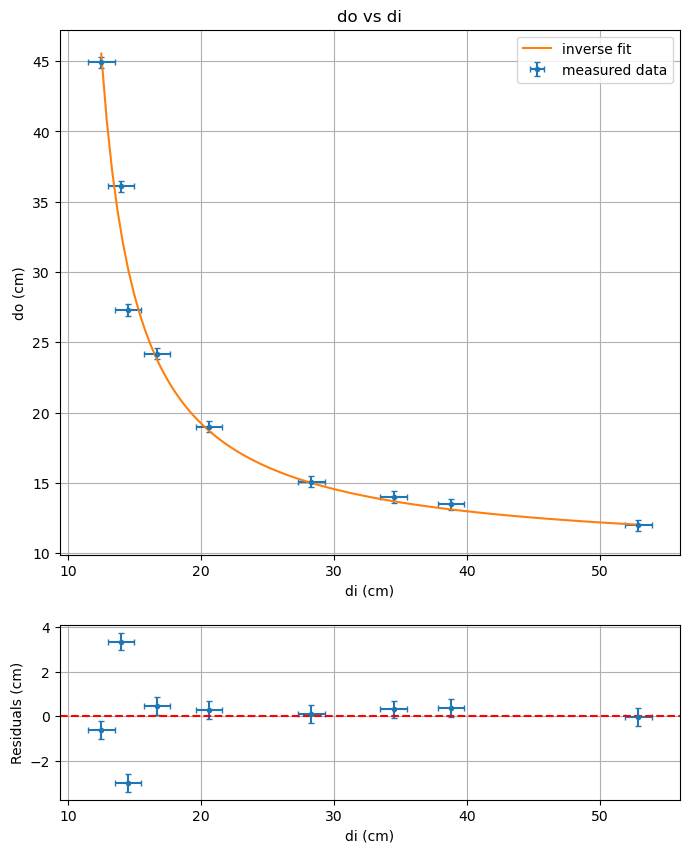

In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def model(x, f):
    return 1/(1/f - 1/x)


# calculate linear fit parameters and their uncertainties
coeff, pcov = curve_fit(model, di, do)
f_lin = coeff[0] 
df_lin = np.sqrt(np.diag(pcov))[0]

# calculate do^2
do_pred = model(di, f_lin)

ss_res = np.sum((do - do_pred) ** 2)              # residual sum of squares
ss_tot = np.sum((do - np.mean(do)) ** 2)          # total sum of squares

r2 = 1 - (ss_res / ss_tot)

print(f"r^2 = {r2:.4f}")

from scipy import stats

# number of data points and parameters
n = len(do)
p = 1  # f and R0

# t-statistic for slope
t_stat = f_lin / df_lin

# degrees of freedom
dof = n - p

# two-sided p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), dof))

print(f"Focal length f = {f_lin:.4f} ± {df_lin:.4f}")
print(f"t = {t_stat:.4f}")
print(f"p-value = {p_value:.4e}")



# calculate fitted values and residuals
di_range = np.linspace(min(di), max(di), 100)
do_fit = model(di_range, f_lin)

res_lin = do - model(di, f_lin)

# plot data, fit, and residuals
fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = ax
ax1.errorbar(di, do, xerr=ddi, yerr=ddo, fmt='.', capsize=2, label='measured data')
ax1.plot(di_range, do_fit, label='inverse fit')
ax1.set_title('do vs di')
ax1.set_xlabel('di (cm)')
ax1.set_ylabel('do (cm)')
ax1.grid(True)
ax1.legend()
ax2.errorbar(di, res_lin, xerr=ddi, yerr=ddo, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('di (cm)')
ax2.set_ylabel('Residuals (cm)')
ax2.grid(True)
plt.show()


#### Grpahing $\frac{1}{d_i}$ vs. $\frac{1}{d_o}$
Linearizing gives $\frac{1}{d_i} = -\frac{1}{d_o} + \frac{1}{f}$, so the intercept of the fit is $b = 1/f$.
With $f$ and the lensmaker equation $\frac{1}{f} = (n-1)\left(\frac{1}{R_1}-\frac{1}{R_2}\right)$, solve for $n$.

slope m = -1.0152 ± 0.0314
intercept b = 0.10230 ± 0.00178
Focal length f = 9.7754 ± 0.1705
Refractive index n = 1.5115 ± 0.0089


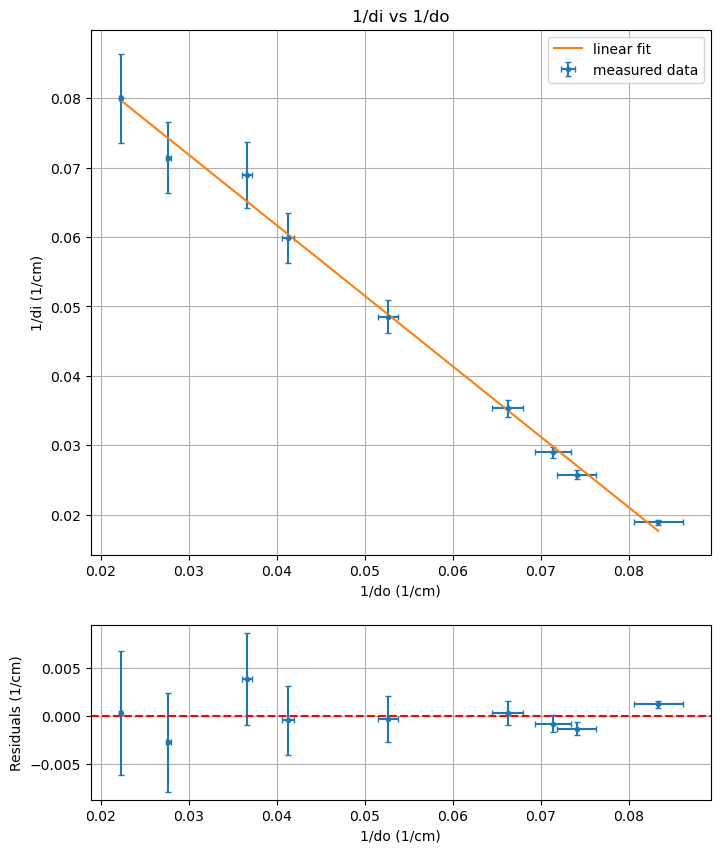

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

inv_di = 1 / di
inv_do = 1 / do

d_inv_di = ddi / di**2
d_inv_do = ddo / do**2

def linear(x, m, b):
    return m * x + b

coeff, pcov = curve_fit(linear, inv_do, inv_di)
m_inv, b_inv = coeff
dm_inv, db_inv = np.sqrt(np.diag(pcov))

f_inv = 1 / b_inv
df_inv = db_inv / b_inv**2

print(f"slope m = {m_inv:.4f} ± {dm_inv:.4f}")
print(f"intercept b = {b_inv:.5f} ± {db_inv:.5f}")
print(f"Focal length f = {f_inv:.4f} ± {df_inv:.4f}")

# lensmaker equation (set radii in cm)
R1 = 10.0
R2 = -10.0
n = 1 + (1 / f_inv) / (1 / R1 - 1 / R2)
dn = (df_inv / f_inv**2) / (1 / R1 - 1 / R2)
print(f"Refractive index n = {n:.4f} ± {dn:.4f}")

inv_do_range = np.linspace(min(inv_do), max(inv_do), 100)
inv_di_fit = linear(inv_do_range, m_inv, b_inv)
res_inv = inv_di - linear(inv_do, m_inv, b_inv)

# plot data, fit, and residuals
fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = ax
ax1.errorbar(inv_do, inv_di, xerr=d_inv_do, yerr=d_inv_di, fmt='.', capsize=2, label='measured data')
ax1.plot(inv_do_range, inv_di_fit, label='linear fit')
ax1.set_title('1/di vs 1/do')
ax1.set_xlabel('1/do (1/cm)')
ax1.set_ylabel('1/di (1/cm)')
ax1.grid(True)
ax1.legend()

ax2.errorbar(inv_do, res_inv, xerr=d_inv_do, yerr=d_inv_di, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('1/do (1/cm)')
ax2.set_ylabel('Residuals (1/cm)')
ax2.grid(True)
plt.show()


#### Graphing $d_i \cdot d_o$ vs. $d_i + d_o$

Multiplying the thin-lens equation gives $d_i d_o = f(d_i + d_o)$, so the plot should be linear.
The line should pass near the origin and its slope is the focal length $f$.

slope m = 9.8962 ± 0.3652
intercept b = -1.8285 ± 18.0464
Focal length f = 9.8962 ± 0.3652


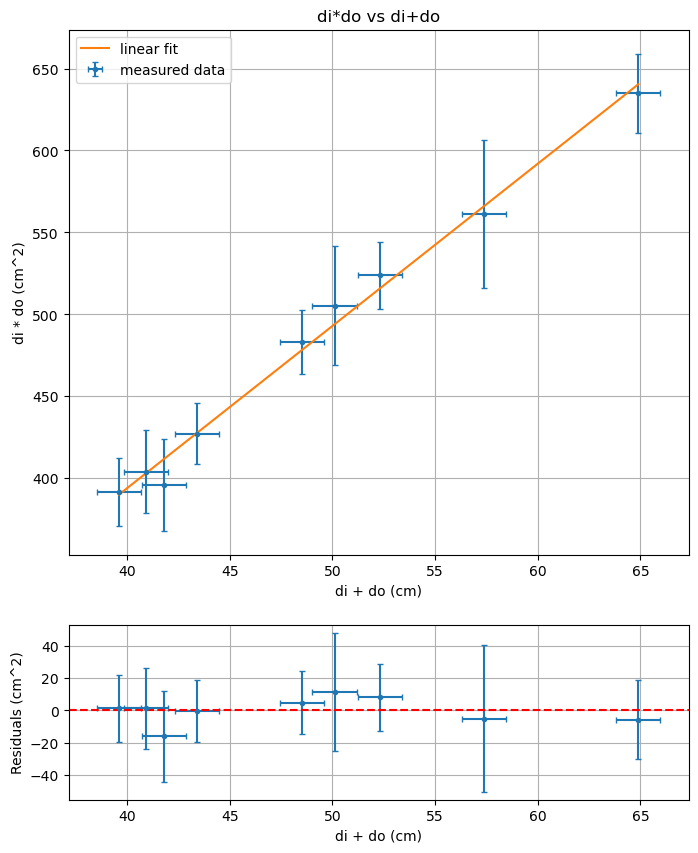

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

sum_d = di + do
prod_d = di * do

d_sum = np.sqrt(ddi**2 + ddo**2)
d_prod = np.sqrt((do * ddi)**2 + (di * ddo)**2)

def linear(x, m, b):
    return m * x + b

coeff, pcov = curve_fit(linear, sum_d, prod_d)
m_prod, b_prod = coeff
dm_prod, db_prod = np.sqrt(np.diag(pcov))

f_prod = m_prod
df_prod = dm_prod

print(f"slope m = {m_prod:.4f} ± {dm_prod:.4f}")
print(f"intercept b = {b_prod:.4f} ± {db_prod:.4f}")
print(f"Focal length f = {f_prod:.4f} ± {df_prod:.4f}")

sum_range = np.linspace(min(sum_d), max(sum_d), 100)
prod_fit = linear(sum_range, m_prod, b_prod)
res_prod = prod_d - linear(sum_d, m_prod, b_prod)

# plot data, fit, and residuals
fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = ax
ax1.errorbar(sum_d, prod_d, xerr=d_sum, yerr=d_prod, fmt='.', capsize=2, label='measured data')
ax1.plot(sum_range, prod_fit, label='linear fit')
ax1.set_title('di*do vs di+do')
ax1.set_xlabel('di + do (cm)')
ax1.set_ylabel('di * do (cm^2)')
ax1.grid(True)
ax1.legend()

ax2.errorbar(sum_d, res_prod, xerr=d_sum, yerr=d_prod, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('di + do (cm)')
ax2.set_ylabel('Residuals (cm^2)')
ax2.grid(True)
plt.show()


##### Discussion
From the nonlinear $d_i$-$d_o$ fit we get $f_{\text{nl}}$. The inverse plot gives $f_{\text{inv}}=1/b$ and the product plot gives $f_{\text{prod}}=m$.
If the three values agree within uncertainties (and with the nominal lens value), the thin-lens model is consistent. Small deviations can come from alignment, finite lens thickness, or reading errors on the scale.

In [6]:
import numpy as np

f_nonlin = f_lin
df_nonlin = df_lin

values = np.array([f_nonlin, f_inv, f_prod])
errors = np.array([df_nonlin, df_inv, df_prod])

weights = 1 / errors**2
f_weighted = np.sum(weights * values) / np.sum(weights)
df_weighted = np.sqrt(1 / np.sum(weights))

print("Focal length comparison (cm):")
print(f"nonlinear fit: {f_nonlin:.4f} ± {df_nonlin:.4f}")
print(f"inverse plot: {f_inv:.4f} ± {df_inv:.4f}")
print(f"product plot: {f_prod:.4f} ± {df_prod:.4f}")
print(f"weighted mean: {f_weighted:.4f} ± {df_weighted:.4f}")


Focal length comparison (cm):
nonlinear fit: 9.8075 ± 0.0597
inverse plot: 9.7754 ± 0.1705
product plot: 9.8962 ± 0.3652
weighted mean: 9.8062 ± 0.0557


#### Two Lenses

*Calculate the predicted position and size of the image and compare with experimental data*

In [7]:
import numpy as np

# measured positions (cm) - replace with your measurements
xO = np.array([0.0])
xL1 = np.array([20.0])
xL2 = np.array([70.0])
xI_meas = np.array([84.4])

# measured sizes (cm)
hO = np.array([2.0])
hI_meas = np.array([0.9])

# focal lengths (cm)
f1 = f_lin
f2 = f_lin  # replace if the second lens differs

do1 = xL1 - xO
di1 = 1 / (1 / f1 - 1 / do1)
xI1 = xL1 + di1

do2 = xL2 - xI1
di2 = 1 / (1 / f2 - 1 / do2)
xI_pred = xL2 + di2

m1 = -di1 / do1
m2 = -di2 / do2
m_tot = m1 * m2
hI_pred = m_tot * hO

print("Predicted image position (cm):", xI_pred)
print("Measured image position (cm):", xI_meas)
print("Predicted image size (cm):", hI_pred)
print("Measured image size (cm):", hI_meas)
print("Total magnification:", m_tot)


Predicted image position (cm): [84.39935877]
Measured image position (cm): [84.4]
Predicted image size (cm): [0.90102183]
Measured image size (cm): [0.9]
Total magnification: [0.45051091]
